In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("All imports successful!")

All imports successful!


In [165]:
#Load the Data
file_path = r"C:\Users\zachs\Downloads\Cleaned_World Energy Consumption.xlsx"
df = pd.read_excel(file_path)

print("Shape:", df.shape)
print(df.head())


Shape: (7889, 129)
         country    year iso_code  population           gdp  \
0  United States  1900.0      USA  74829905.0  6.139980e+11   
1  United States  1901.0      USA  76245912.0  6.831060e+11   
2  United States  1902.0      USA  77698268.0  6.901270e+11   
3  United States  1903.0      USA  79187838.0  7.237660e+11   
4  United States  1904.0      USA  80705948.0  7.146220e+11   

   biofuel_cons_change_pct  biofuel_cons_change_twh  biofuel_cons_per_capita  \
0                      NaN                      NaN                      NaN   
1                      NaN                      NaN                      NaN   
2                      NaN                      NaN                      NaN   
3                      NaN                      NaN                      NaN   
4                      NaN                      NaN                      NaN   

   biofuel_consumption  biofuel_elec_per_capita  ...  solar_share_elec  \
0                  NaN                      NaN

In [166]:
#Clean the Data
df = df[(df['year'] >= 2000) & (df['year'] <= 2020)].copy()

print("Rows after filtering by year:", subset.shape)
print("Number of Countries:", df['country'].nunique())
subset[['country','year']].head()

#Create another data set for analysis
df_clean = df.copy()

#Create new features
#gdp per capita
df_clean['gdp_per_capita'] = df_clean['gdp'] / df_clean['population']
#Shared Renewables
df_clean['renewables_share'] = (
    df_clean['hydro_energy_per_capita'] +
    df_clean['wind_energy_per_capita'] +
    df_clean['solar_energy_per_capita']
) / df_clean['energy_per_capita']

model_df = df_clean[features + [target]].copy()

Rows after filtering by year: (483, 129)
Number of Countries: 78


In [167]:
#Pick Target
target = "renewables_share_energy"

#Pick input features
features = ['gdp_per_capita', 'renewables_share', 'coal_elec_per_capita', 'oil_energy_per_capita', 'hydro_energy_per_capita', 'wind_energy_per_capita', 'greenhouse_gas_emissions', 'nuclear_energy_per_capita'
    #"year",
    #"population",
    #"gdp",
    #"energy_per_capita",
    #"electricity_generation",
    #"primary_energy_consumption",
    #"coal_share_energy",
    #"gas_share_energy",
    #"oil_share_energy"
]

#Keep only needed columns
model_df = df_clean[features + [target]].copy()

#Drop rows where target is missing
model_df = model_df.dropna(subset=[target])

print("Model dataframe shape:", model_df.shape)
print(model_df[features + [target]].isna().sum())

Model dataframe shape: (1277, 9)
gdp_per_capita               175
renewables_share              12
coal_elec_per_capita           0
oil_energy_per_capita          0
hydro_energy_per_capita        0
wind_energy_per_capita         0
greenhouse_gas_emissions       0
nuclear_energy_per_capita    548
renewables_share_energy        0
dtype: int64


In [168]:
#Train Test Split
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [169]:
#Preproccessing and Model Pipeline
numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Train model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('nn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse mat

In [170]:
#Pred
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nNeural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)




Neural Network Regression Results
---------------------------------
MSE : 2.0781766828519013
RMSE: 1.4415882501088517
MAE : 0.9258018714630479
R^2 : 0.9895053364699521


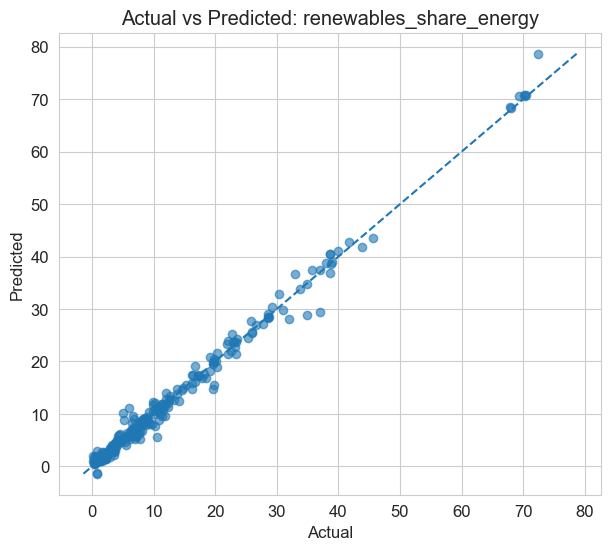

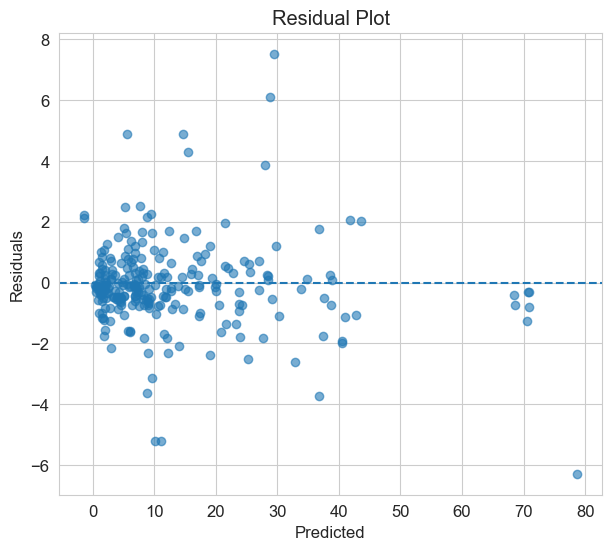

In [171]:
#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()